
<style>
/* Persian / RTL presentation */
.fa-rtl {
  direction: rtl;
  text-align: right;
  font-family: Tahoma, Arial, "Noto Sans Arabic", sans-serif;
  line-height: 2.0;
  font-size: 16px;
  unicode-bidi: plaintext;
}

/* Keep technical elements LTR */
.fa-rtl code,
.fa-rtl pre,
.fa-rtl .highlight,
.fa-rtl kbd,
.fa-rtl samp {
  direction: ltr !important;
  text-align: left !important;
  unicode-bidi: isolate !important;
  font-family: "Roboto Mono", "DejaVu Sans Mono", Consolas, monospace;
  line-height: 1.55;
}

.fa-rtl table {
  direction: rtl;
  text-align: right;
  margin-right: 0;
}

.fa-rtl th,
.fa-rtl td {
  text-align: right !important;
  vertical-align: top;
}

.fa-rtl ul,
.fa-rtl ol {
  padding-right: 1.5em;
  padding-left: 0;
}

.fa-rtl blockquote {
  border-right: 4px solid #ccc;
  border-left: 0;
  margin-right: 0;
  padding-right: 1em;
  padding-left: 0;
}

.fa-rtl h1,
.fa-rtl h2,
.fa-rtl h3,
.fa-rtl h4 {
  text-align: right;
  line-height: 1.6;
}

/* Inline English / numeric fragments behave more predictably */
.fa-rtl .ltr {
  direction: ltr;
  unicode-bidi: isolate;
  display: inline-block;
}
</style>

<div class="fa-rtl" dir="rtl">

# Machine Learning with Python — Session 1
## Python Fundamentals & Machine Learning Workflow

**مدرس:** Hamed Naseri  
**مدت:** ۲ ساعت  
**زبان توضیحات:** فارسی + اصطلاحات اصلی انگلیسی  
**سبک کلاس:** توضیح کوتاه → مثال → Live Coding → Quiz → تمرین

---

### هدف جلسه

در پایان این جلسه انتظار می‌رود دانشجو بتواند:

1. مفهوم **Machine Learning** را به‌صورت کاربردی توضیح دهد.
2. تفاوت **Supervised** و **Unsupervised Learning** را بداند.
3. تفاوت **Regression** و **Classification** را تشخیص دهد.
4. با چند دستور ضروری Python، NumPy و Pandas کار کند.
5. مفهوم **Features (`X`)** و **Target (`y`)** را تشخیص دهد.
6. دلیل استفاده از **Train/Test Split** را توضیح دهد.
7. یک **Baseline Model** بسازد.
8. اولین مدل Scikit-learn را با الگوی `fit → predict → evaluate` اجرا کند.
9. مفهوم‌های **Generalization، Overfitting و Data Leakage** را در سطح مقدماتی بفهمد.

> هدف جلسه اول یادگیری عمیق Linear Regression یا Classification نیست؛ هدف، ساختن یک تصویر روشن از **کل workflow یادگیری ماشین** است.

</div>


<div class="fa-rtl" dir="rtl">

> **نکته نمایش:** متن فارسی عمداً راست‌چین است، اما کدها و عبارت‌های فنی مانند `X_train`, `fit()`, `Regression` و `Train/Test Split` به‌صورت چپ‌به‌راست نمایش داده می‌شوند.

</div>


<div class="fa-rtl" dir="rtl">

# 1. Machine Learning چیست؟

در برنامه‌نویسی سنتی معمولاً **قواعد** را خودمان می‌نویسیم.

اما در Machine Learning، مدل تلاش می‌کند **الگوها را از داده یاد بگیرد**.

مثلاً برای پیش‌بینی تعداد سفرهای روزانه:

$$
\text{age, income, car ownership, travel time}
\rightarrow
\text{number of trips}
$$
$$
\text{age, gender, education, experience}
\rightarrow
\text{income}
$$
به‌صورت ساده:

- `X` = اطلاعاتی که برای پیش‌بینی استفاده می‌کنیم.
- `y` = چیزی که می‌خواهیم پیش‌بینی کنیم.

### نکته کلیدی

Machine Learning جادو نیست. اگر داده نامناسب، ناقص یا غیرنماینده باشد، حتی مدل پیچیده هم الزاماً نتیجه خوبی نمی‌دهد.

</div>


<div class="fa-rtl" dir="rtl">

## انواع اصلی Machine Learning

### Supervised Learning
Target مشخص داریم.

**Regression:** مقدار هدف عددی است.  
مثال: قیمت خانه، حجم ترافیک، زمان سفر.

**Classification:** مقدار هدف یک کلاس یا دسته است.  
مثال: بله/خیر، Spam/Not Spam، Car/Bus/Bike.

### Unsupervised Learning
Target مشخص نداریم و دنبال ساختار در داده هستیم.

مثال: **Clustering** برای گروه‌بندی مسافران با رفتار مشابه.

</div>


<div class="fa-rtl" dir="rtl">

## Quiz 1 — نوع مسئله را مشخص کنید

برای هر مورد بگویید **Regression، Classification یا Unsupervised Learning**:

1. پیش‌بینی حجم ترافیک فردا
2. پیش‌بینی اینکه یک مشتری سرویس را لغو می‌کند یا نه
3. گروه‌بندی مشتریان بر اساس رفتار خرید
4. پیش‌بینی قیمت یک خانه
5. تشخیص نوع وسیله سفر: Car / Bus / Bike

<details>
<summary><b>نمایش پاسخ</b></summary>

1. Regression  
2. Classification  
3. Unsupervised Learning / Clustering  
4. Regression  
5. Classification

</details>

</div>


<div class="fa-rtl" dir="rtl">

# 2. Python Essentials — فقط چیزهایی که برای ML لازم داریم

در این دوره هدف، آموزش کامل Python نیست. فقط چند مفهوم را مرور می‌کنیم که مرتب در تحلیل داده استفاده می‌شوند:

- Variables
- Lists
- Conditions
- Functions

Loops را فقط در حد آشنایی می‌بینیم، چون بسیاری از عملیات داده با NumPy و Pandas بدون loop انجام می‌شوند.

</div>


In [ ]:
#how to create variables

age = 34
income = 62500.50
city = "Quebec City"
car_owner = True

print(age, income, city, car_owner)
print(type(age), type(income), type(city), type(car_owner))


34 62500.5 Quebec City True
<class 'int'> <class 'float'> <class 'str'> <class 'bool'>


In [ ]:
# how to make a lost?

travel_times = [25, 40, 18, 55, 32]

print("First:", travel_times[0])
print("Last:", travel_times[-1])
print("Count:", len(travel_times))


First: 25
Last: 32
Count: 5


In [40]:
# creating a loop

trip_time = 34


if trip_time > 30:
    print("Long trip")
else:
    print("Short trip")


Long trip


In [ ]:
#making a function (use everytime it is needed)

def minutes_to_hours(minutes):
    return minutes / 60

print(minutes_to_hours(90))


<div class="fa-rtl" dir="rtl">

### تمرین 1 — Python

تابعی به نام `classify_trip` بنویسید:

- اگر زمان سفر بیشتر از ۳۰ دقیقه بود `"Long"` برگرداند.
- در غیر این صورت `"Short"` برگرداند.

</div>


In [ ]:
# To do
def classify_trip(minutes):


# Test your function:
# print(classify_trip(45))
# print(classify_trip(20))


<div class="fa-rtl" dir="rtl">

<details>
<summary><b>نمونه پاسخ تمرین 1</b></summary>

```python
def classify_trip(minutes):
    if minutes > 30:
        return "Long"
    return "Short"
```

</details>

</div>


<div class="fa-rtl" dir="rtl">

## NumPy Essentials

NumPy برای محاسبات عددی سریع و **vectorized operations** استفاده می‌شود.

ایده اصلی: به‌جای اینکه روی تک‌تک مقادیر loop بزنیم، روی کل array عملیات انجام می‌دهیم.

</div>


In [42]:
import numpy as np

times = np.array([25, 40, 18, 55, 32])

print("Minutes:", times)
print("Hours:", times / 60)
print("Mean:", times.mean())
print("Max:", times.max())
print("Trips > 30 min:", times[times > 30])


Minutes: [25 40 18 55 32]
Hours: [0.41666667 0.66666667 0.3        0.91666667 0.53333333]
Mean: 34.0
Max: 55
Trips > 30 min: [40 55 32]


<div class="fa-rtl" dir="rtl">

### Quiz 2 — NumPy

اگر داشته باشیم:

```python
x = np.array([10, 20, 30, 40])
```

خروجی `x[x > 20]` چیست؟

A) `[10, 20]`  
B) `[20, 30, 40]`  
C) `[30, 40]`  
D) Error

<details>
<summary><b>پاسخ</b></summary>

**C) `[30, 40]`**

</details>

</div>


<div class="fa-rtl" dir="rtl">

# 3. Pandas — ابزار اصلی داده‌های جدولی

در Pandas مهم‌ترین ساختار، **DataFrame** است.

- Row = Observation
- Column = Variable

در Machine Learning تقریباً همیشه قبل از مدل‌سازی، DataFrame را بررسی می‌کنیم.

</div>


In [48]:
import pandas as pd

df = pd.DataFrame({
    "age": [22, 35, 47, 29, 61, 41],
    "income": [35000, 62000, 81000, 47000, 73000, 68000],
    "car_owner": [0, 1, 1, 0, 1, 1],
    "weekly_trips": [18, 12, 9, 20, 7, 11],
    "mode": ["Bus", "Car", "Car", "Bus", "Car", "Car"]
})

df


,age,income,car_owner,weekly_trips,mode
0,22,35000.3,0,18,Bus
1,35,62000.0,1,12,Car
2,47,81000.0,1,9,Car
3,29,47000.0,0,20,Bus
4,61,73000.0,1,7,Car
5,41,68000.0,1,11,Car


<div class="fa-rtl" dir="rtl">

## پنج دستور مهم Pandas

در شروع کار با یک dataset معمولاً این‌ها بسیار کاربردی‌اند:

```python
df.head()
df.shape
df.info()
df.describe()
df.isna().sum()
```

</div>


In [49]:
display(df.head())

print("Shape:", df.shape)

print("\nInfo:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())


,age,income,car_owner,weekly_trips,mode
0,22,35000.3,0,18,Bus
1,35,62000.0,1,12,Car
2,47,81000.0,1,9,Car
3,29,47000.0,0,20,Bus
4,61,73000.0,1,7,Car


Shape: (6, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           6 non-null      int64  
 1   income        6 non-null      float64
 2   car_owner     6 non-null      int64  
 3   weekly_trips  6 non-null      int64  
 4   mode          6 non-null      object 
dtypes: float64(1), int64(3), object(1)
memory usage: 372.0+ bytes

Descriptive statistics:


,age,income,car_owner,weekly_trips
count,6.000000,6.00000,6.000000,6.000000
mean,39.166667,61000.05000,0.666667,12.833333
std,13.833534,17122.99273,0.516398,5.115336
min,22.000000,35000.30000,0.000000,7.000000
25%,30.500000,50750.00000,0.250000,9.500000
50%,38.000000,65000.00000,1.000000,11.500000
75%,45.500000,71750.00000,1.000000,16.500000
max,61.000000,81000.00000,1.000000,20.000000


<div class="fa-rtl" dir="rtl">

## Selecting & Filtering

</div>


In [54]:
# One column
display(df["age"])
print(df["age"])

# Several columns
display(df[["age", "income", "weekly_trips"]])

# Filter rows
display(df[df["age"] < 40])


,age
0,22
1,35
2,47
3,29
4,61
5,41


0    22
1    35
2    47
3    29
4    61
5    41
Name: age, dtype: int64


,age,income,weekly_trips
0,22,35000.3,18
1,35,62000.0,12
2,47,81000.0,9
3,29,47000.0,20
4,61,73000.0,7
5,41,68000.0,11


,age,income,car_owner,weekly_trips,mode
0,22,35000.3,0,18,Bus
1,35,62000.0,1,12,Car
3,29,47000.0,0,20,Bus


<div class="fa-rtl" dir="rtl">

### تمرین 2 — Pandas

با DataFrame بالا:

1. فقط ستون‌های `income` و `weekly_trips` را نمایش دهید.
2. فقط افراد با `income > 60000` را انتخاب کنید.
3. تعداد ردیف‌ها و ستون‌ها را چاپ کنید.
4. میانگین `weekly_trips` را محاسبه کنید.

</div>


In [ ]:
# TODO 1
# df[...]


# TODO 2
# df[...]


# TODO 3
# print(...)


# TODO 4
# print(...)


<div class="fa-rtl" dir="rtl">

<details>
<summary><b>نمونه پاسخ تمرین 2</b></summary>

```python
df[["income", "weekly_trips"]]

df[df["income"] > 60000]

print(df.shape)

print(df["weekly_trips"].mean())
```

</details>

</div>


<div class="fa-rtl" dir="rtl">

# 4. Missing Values و Exploratory Data Analysis (EDA)

داده واقعی معمولاً تمیز و کامل نیست.

قبل از مدل‌سازی حداقل این موارد را بررسی کنید:

- Missing values
- Distribution
- Outliers
- روابط اولیه بین متغیرها
- خطاهای واضح در داده

</div>


In [55]:
df_missing = df.copy()

df_missing.loc[2, "income"] = np.nan
df_missing.loc[4, "weekly_trips"] = np.nan

df_missing


,age,income,car_owner,weekly_trips,mode
0,22,35000.3,0,18.0,Bus
1,35,62000.0,1,12.0,Car
2,47,NaN,1,9.0,Car
3,29,47000.0,0,20.0,Bus
4,61,73000.0,1,NaN,Car
5,41,68000.0,1,11.0,Car


In [56]:
df_missing.isna().sum()


,0
age,0
income,1
car_owner,0
weekly_trips,1
mode,0


<div class="fa-rtl" dir="rtl">

## یک مثال ساده از Imputation

برای یک متغیر عددی می‌توان مقدار گمشده را با median جایگزین کرد.



</div>


In [57]:
median_income = df_missing["income"].median()
df_missing["income_filled"] = df_missing["income"].fillna(median_income)

df_missing


,age,income,car_owner,weekly_trips,mode,income_filled
0,22,35000.3,0,18.0,Bus,35000.3
1,35,62000.0,1,12.0,Car,62000.0
2,47,NaN,1,9.0,Car,62000.0
3,29,47000.0,0,20.0,Bus,47000.0
4,61,73000.0,1,NaN,Car,73000.0
5,41,68000.0,1,11.0,Car,68000.0


<div class="fa-rtl" dir="rtl">

## EDA سریع

هدف نمودار فقط «رسم کردن» نیست. باید از خودتان بپرسید:

- Distribution چگونه است؟
- Outlier داریم؟
- رابطه‌ای دیده می‌شود؟
- مقدار غیرمنطقی وجود دارد؟

</div>


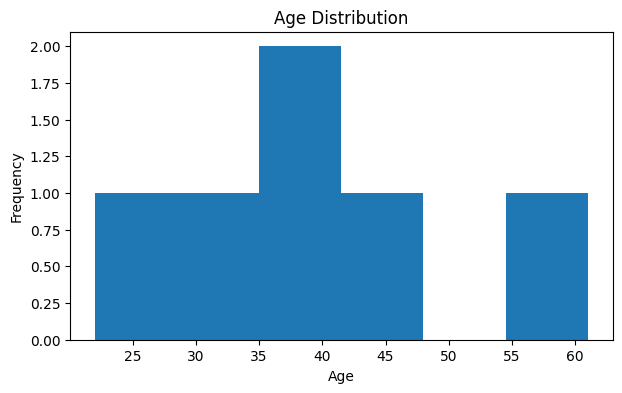

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(df["age"], bins=6)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()


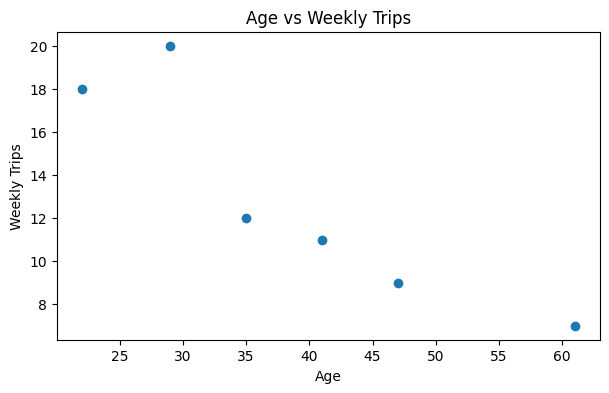

In [61]:
plt.figure(figsize=(7, 4))
plt.scatter(df["age"], df["weekly_trips"])
plt.xlabel("Age")
plt.ylabel("Weekly Trips")
plt.title("Age vs Weekly Trips")
plt.show()


<div class="fa-rtl" dir="rtl">

### تمرین 3 — تفسیر نمودار

به نمودار `Age vs Weekly Trips` نگاه کنید و در **یک یا دو جمله** پاسخ دهید:

1. آیا با این داده کوچک رابطه‌ای بین سن و تعداد سفر هفتگی دیده می‌شود؟
2. آیا از این نمودار می‌توان نتیجه گرفت سن **علت** کاهش/افزایش سفر است؟

> نکته: **Correlation/association ≠ Causation**

</div>


<div class="fa-rtl" dir="rtl">

# 5. Features (`X`) و Target (`y`)

در Supervised Learning:

- **Features (`X`)** = متغیرهایی که برای پیش‌بینی استفاده می‌شوند.
- **Target (`y`)** = متغیری که می‌خواهیم پیش‌بینی کنیم.

مثلاً اگر هدف پیش‌بینی `weekly_trips` باشد:

```python
X = df[["age", "income", "car_owner"]]
y = df["weekly_trips"]
```

</div>


In [62]:
X_demo = df[["age", "income", "car_owner"]]
y_demo = df["weekly_trips"]

display(X_demo.head())
display(y_demo.head())


,age,income,car_owner
0,22,35000.3,0
1,35,62000.0,1
2,47,81000.0,1
3,29,47000.0,0
4,61,73000.0,1


,weekly_trips
0,18
1,12
2,9
3,20
4,7


<div class="fa-rtl" dir="rtl">

## Machine Learning Workflow

این workflow را در کل دوره بارها تکرار می‌کنیم:

```text
Define Problem
      ↓
Load / Inspect Data
      ↓
EDA / Cleaning
      ↓
Define X and y
      ↓
Train/Test Split
      ↓
Baseline
      ↓
Train Model
      ↓
Predict
      ↓
Evaluate
      ↓
Interpret
```

> **Machine Learning یک workflow است، نه فقط یک algorithm.**

</div>


<div dir="rtl">

## Quiz 3 — X و y

اگر هدف، پیش‌بینی `weekly_trips` از روی `age`, `income`, `car_owner` باشد:

کدام گزینه صحیح است؟

</div>

<div dir="ltr">

A) `X = weekly_trips` , `y = age, income, car_owner`  
B) `X = age, income, car_owner` , `y = weekly_trips`  
C) Both are the same  
D) Target is not required

</div>

<div dir="rtl">

<details>
<summary><b>نمایش پاسخ</b></summary>

✅ **پاسخ صحیح: B**

`X` شامل Featureهایی است که مدل برای پیش‌بینی استفاده می‌کند:

`age`, `income`, `car_owner`

و `y` همان Target است که می‌خواهیم پیش‌بینی کنیم:

`weekly_trips`

بنابراین:

`X = age, income, car_owner`

`y = weekly_trips`

</div>

<div dir="ltr">



</div>

<div dir="rtl">

</details>

</div>

<div class="fa-rtl" dir="rtl">

# 6. Train/Test Split — چرا داده را تقسیم می‌کنیم؟

اگر مدل را روی همان داده‌ای ارزیابی کنیم که با آن آموزش دیده، ممکن است عملکردش بیش از حد خوب به نظر برسد.

هدف واقعی این است که ببینیم مدل روی **داده ندیده (unseen data)** چگونه عمل می‌کند.

### Training Set
برای آموزش مدل.

### Test Set
برای ارزیابی نهایی روی داده‌ای که مدل هنگام آموزش ندیده است.

در جلسات بعد با **Validation Set** و **Cross-Validation** نیز کار می‌کنیم.

</div>


<div class="fa-rtl" dir="rtl">

# 7. اولین Regression Workflow

برای تمرین workflow از dataset داخلی Scikit-learn استفاده می‌کنیم.

Target عددی است، پس مسئله **Regression** است.

هدف فعلاً فهمیدن workflow است، نه تحلیل تخصصی dataset.

</div>


In [74]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)

X_reg = diabetes.data
y_reg = diabetes.target

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

display(X_reg.head())
display(y_reg.head())
print("Average of y_reg:" ,y_reg.mean())
print("Max of y_reg:", y_reg.max())
print("Min of y_reg: ", y_reg.min())

X shape: (442, 10)
y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


Average of y_reg: 152.13348416289594
Max of y_reg: 346.0
Min of y_reg:  25.0


### Diabetes Dataset — متغیرها

| Variable | توضیح |
|---|---|
| `age` | سن |
| `sex` | جنسیت |
| `bmi` | شاخص توده بدنی |
| `bp` | میانگین فشار خون |
| `s1` | کل کلسترول خون |
| `s2` | LDL |
| `s3` | HDL |
| `s4` | نسبت کل کلسترول به HDL |
| `s5` | یک شاخص مرتبط با تری‌گلیسرید خون |
| `s6` | قند خون |

### Target

`target` = میزان پیشرفت بیماری دیابت پس از یک سال

چون Target عددی است، این مسئله از نوع **Regression** است.

<div class="fa-rtl" dir="rtl">

## Split Data

</div>


In [75]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 0

X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (353, 10)
X_test: (89, 10)
y_train: (353,)
y_test: (89,)


<div class="fa-rtl" dir="rtl">

### نکته

`test_size=0.20` یعنی ۲۰٪ داده برای Test Set کنار گذاشته می‌شود.

`random_state=0` باعث می‌شود تقسیم داده قابل تکرار (**reproducible**) باشد. عدد 0 ویژگی خاصی ندارد؛ هر عدد ثابت دیگری هم قابل استفاده است.

</div>


<div class="fa-rtl" dir="rtl">

## Baseline Model

قبل از اینکه یک مدل واقعی را تحسین کنیم، باید ببینیم آیا از یک روش خیلی ساده بهتر است یا نه.

برای Regression می‌توانیم یک baseline بسازیم که برای همه، میانگین Target را پیش‌بینی کند.

</div>


In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline R²:", baseline_r2)


<div class="fa-rtl" dir="rtl">

## اولین مدل Scikit-learn

تقریباً همه مدل‌های Scikit-learn از یک الگوی ساده پیروی می‌کنند:

```python
model = Model(...)
model.fit(X_train, y_train)
pred = model.predict(X_test)
metric(y_test, pred)
```

این الگو را به خاطر بسپارید.

</div>


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

model_mae = mean_absolute_error(y_test, y_pred)
model_r2 = r2_score(y_test, y_pred)

print("Linear Regression MAE:", model_mae)
print("Linear Regression R²:", model_r2)


<div class="fa-rtl" dir="rtl">

## مقایسه Model با Baseline

فعلاً دو metric کافی است:

### MAE
میانگین قدر مطلق خطاها. **کمتر بهتر است.**

### R²
در این مثال نشان می‌دهد مدل نسبت به پیش‌بینی ساده‌ی میانگین چه‌قدر بهتر عمل می‌کند.

- `R² = 1` → پیش‌بینی کامل
- `R² = 0` → تقریباً هم‌سطح baseline میانگین
- `R² < 0` → بدتر از baseline

جزئیات این metricها در جلسه Regression بررسی می‌شود.

</div>


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Mean Baseline", "Linear Regression"],
    "MAE": [baseline_mae, model_mae],
    "R2": [baseline_r2, model_r2]
})

comparison


In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


<div class="fa-rtl" dir="rtl">

### Quiz 4 — Workflow

ترتیب درست کدام است؟

A) `predict → fit → split → evaluate`  
B) `split → fit → predict → evaluate`  
C) `fit → evaluate → split → predict`  
D) `evaluate → split → fit → predict`

<details>
<summary><b>پاسخ</b></summary>

**B) `split → fit → predict → evaluate`**

</details>

</div>


<div class="fa-rtl" dir="rtl">

# 8. Generalization، Overfitting و Data Leakage

## Generalization
توانایی مدل برای عملکرد مناسب روی داده‌های جدید و ندیده.

## Underfitting
مدل آن‌قدر ساده است که حتی الگوهای مهم Training Data را هم خوب یاد نمی‌گیرد.

## Overfitting
مدل Training Data را بیش از حد یاد می‌گیرد و روی داده جدید ضعیف‌تر عمل می‌کند.

هدف اصلی، بهترین عملکرد روی Training Data نیست؛ هدف، عملکرد خوب روی **unseen data** است.

</div>


<div class="fa-rtl" dir="rtl">

## Data Leakage

Leakage زمانی رخ می‌دهد که مدل به اطلاعاتی دسترسی پیدا کند که در زمان پیش‌بینی واقعی نباید در اختیارش باشد.

مثال:

فرض کنید می‌خواهیم پیش‌بینی کنیم یک مشتری ماه بعد سرویس را لغو می‌کند یا نه.

اگر Featureای مثل `account_closed_date` داشته باشیم، ممکن است پاسخ را عملاً از قبل لو بدهد.

### یک قانون ساده

> هر Feature باید در **زمان واقعی پیش‌بینی** در دسترس باشد.

</div>


<div class="fa-rtl" dir="rtl">

### Leakage در Preprocessing

روش اشتباه:

```python
scaler.fit(X)      # sees test data too
X_scaled = scaler.transform(X)
train_test_split(X_scaled, y)
```

ایده امن‌تر:

```python
X_train, X_test, y_train, y_test = train_test_split(X, y)

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

بعداً با `Pipeline` این کار را استانداردتر انجام می‌دهیم.

</div>


<div class="fa-rtl" dir="rtl">

### Quiz 5 — Leakage یا نه؟

می‌خواهیم پیش‌بینی کنیم یک مسافر **ماه آینده** چند سفر با مترو خواهد داشت.

کدام Feature مشکل جدی Leakage دارد؟

A) تعداد سفرهای مترو در ماه گذشته  
B) سن فرد  
C) درآمد فعلی  
D) تعداد سفرهای مترو در ماه آینده

<details>
<summary><b>پاسخ</b></summary>

**D** — چون این اطلاعات در زمان پیش‌بینی هنوز در دسترس نیست.

</details>

</div>


<div class="fa-rtl" dir="rtl">

# 9. تمرین اصلی کلاس — Complete ML Workflow

این تمرین را بدون کپی کردن مستقیم کد قبلی انجام دهید.

فقط از Feature `bmi` در dataset قبلی استفاده کنید.

### کارهایی که باید انجام دهید

1. `X_one` را فقط با ستون `bmi` بسازید.
2. Train/Test Split با `test_size=0.2` و `random_state=42` انجام دهید.
3. یک `DummyRegressor(strategy="mean")` بسازید.
4. یک `LinearRegression` بسازید.
5. برای هر دو مدل MAE محاسبه کنید.
6. برای Linear Regression مقدار R² را محاسبه کنید.
7. در یک جمله بنویسید آیا Linear Regression از baseline بهتر است یا نه.

</div>


In [ ]:
# STEP 1 — Define X and y
feature_name = "bmi"

X_one = X_reg[[feature_name]]
y_one = y_reg

X_one.head()


In [ ]:
# STEP 2 — Train/Test Split
# TODO:
# X_train_one, X_test_one, y_train_one, y_test_one = train_test_split(...)


In [ ]:
# STEP 3 — Baseline
# TODO:
# baseline_one = DummyRegressor(...)
# baseline_one.fit(...)
# baseline_one_pred = ...


In [ ]:
# STEP 4 — Linear Regression
# TODO:
# model_one = LinearRegression()
# model_one.fit(...)
# y_pred_one = ...


In [ ]:
# STEP 5 — Evaluate and compare
# TODO:
# print("Baseline MAE:", ...)
# print("Model MAE:", ...)
# print("Model R²:", ...)


<div class="fa-rtl" dir="rtl">

<details>
<summary><b>راهنمای تمرین اصلی</b></summary>

اگر گیر کردید، workflow را به همین ترتیب دنبال کنید:

```text
X/y
↓
split
↓
baseline.fit
↓
baseline.predict
↓
model.fit
↓
model.predict
↓
MAE / R²
```

</details>

</div>


<div class="fa-rtl" dir="rtl">

## Challenge اختیاری

اگر تمرین را زود تمام کردید:

1. Feature دیگری به‌جای `bmi` انتخاب کنید.
2. همان workflow را تکرار کنید.
3. MAE دو مدل تک‌متغیره را مقایسه کنید.

سؤال:

> آیا بهتر بودن یک Feature برای prediction به معنی رابطه علّی (causal) است؟

**خیر. Predictive association به‌تنهایی causation را اثبات نمی‌کند.**

</div>


<div class="fa-rtl" dir="rtl">

# 10. Exit Quiz

بدون نگاه کردن به بالا پاسخ دهید:

1. تفاوت Regression و Classification چیست؟
2. `X` و `y` چه هستند؟
3. چرا داده را به Train و Test تقسیم می‌کنیم؟
4. Baseline چه کمکی می‌کند؟
5. ترتیب سه عمل اصلی مدل چیست: `fit`, `predict`, `evaluate`؟
6. MAE کمتر بهتر است یا بیشتر؟
7. Overfitting یعنی چه؟
8. Data Leakage یعنی چه؟
9. `random_state` چه کاربردی دارد؟
10. چرا نباید Test Set را در زمان آموزش مدل استفاده کنیم؟

<details>
<summary><b>پاسخ‌های کوتاه</b></summary>

1. Regression برای Target عددی؛ Classification برای Target دسته‌ای.
2. `X` Features و `y` Target است.
3. برای ارزیابی روی داده ندیده.
4. یک مرجع ساده برای قضاوت درباره ارزش مدل ایجاد می‌کند.
5. `fit → predict → evaluate`
6. کمتر.
7. یادگیری بیش از حد Training Data و ضعف روی داده جدید.
8. ورود اطلاعات غیرمجاز/آینده/Test به فرآیند آموزش.
9. Reproducibility.
10. چون Test Set باید نماینده داده واقعاً ندیده باشد.

</details>

</div>


<div class="fa-rtl" dir="rtl">

# Homework

با همان Regression dataset:

1. تعداد rows و columns را گزارش کنید.
2. سه Feature را انتخاب کنید.
3. Missing values را بررسی کنید.
4. `X` و `y` را بسازید.
5. Train/Test Split انجام دهید.
6. Mean Baseline بسازید.
7. Linear Regression آموزش دهید.
8. MAE و R² را گزارش کنید.
9. یک نمودار `Actual vs Predicted` رسم کنید.
10. در ۳ تا ۵ جمله نتیجه را تفسیر کنید.

### Deliverable
یک Colab Notebook شامل code، output و توضیح کوتاه.

</div>


<div class="fa-rtl" dir="rtl">

# جمع‌بندی جلسه

پیام اصلی جلسه اول:

```text
Problem
  ↓
Data
  ↓
Inspection / EDA
  ↓
X + y
  ↓
Train / Test
  ↓
Baseline
  ↓
Model.fit()
  ↓
Model.predict()
  ↓
Evaluation
  ↓
Interpretation
```

> **Machine Learning is a workflow, not just an algorithm.**

</div>


<div class="fa-rtl" dir="rtl">

# جلسه بعد — Linear Regression & Correlation

در Session 2 وارد جزئیات بیشتری می‌شویم:

- Simple Linear Regression
- Multiple Linear Regression
- Regression Coefficients
- Linear Regression Assumptions
- Pearson Correlation
- Spearman Correlation
- Correlation Matrix
- Correlation vs. Causation
- MAE, MSE, RMSE, R²

</div>
